# Predicting Customer Churn in E-commerce

## Business Problem

Customer acquisition is expensive, and losing existing customers directly impacts revenue.
This project aims to build a machine learning model that predicts which customers are likely to churn so that proactive retention strategies can be deployed.

If we can identify at-risk customers early, the business can:
- Send targeted discounts
- Launch retention campaigns
- Trigger proactive customer engagement

## Objective

Develop a classification model to:
- Identify high-risk customers
- Evaluate model performance
- Extract actionable business insights






### Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


### Load the dataset

In [2]:
df = pd.read_excel("ecommerce_churn.xlsx")

df.head()

,UserID,VisitsLast30Days,TimeOnSite,PurchaseCount,HasSupportTicket,Churned
0,5001,41,7.2,0,No,Yes
1,5002,34,15.2,8,No,No
2,5003,6,13.3,5,No,Yes
3,5004,15,17.1,6,Yes,Yes
4,5005,25,13.5,9,Yes,No


### Data Overview (EDA Part 1)

In [3]:
df.shape

(50, 6)

In [4]:
# Checking datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   UserID            50 non-null     int64  
 1   VisitsLast30Days  50 non-null     int64  
 2   TimeOnSite        50 non-null     float64
 3   PurchaseCount     50 non-null     int64  
 4   HasSupportTicket  50 non-null     object 
 5   Churned           50 non-null     object 
dtypes: float64(1), int64(3), object(2)
memory usage: 2.5+ KB


In [5]:
# Checking statistical values
df.describe()

,UserID,VisitsLast30Days,TimeOnSite,PurchaseCount
count,50.00000,50.000000,50.000000,50.000000
mean,5025.50000,25.540000,11.700000,4.840000
std,14.57738,14.758201,5.618337,2.845404
min,5001.00000,0.000000,1.300000,0.000000
25%,5013.25000,15.000000,7.050000,3.000000
50%,5025.50000,26.500000,11.900000,5.000000
75%,5037.75000,35.750000,17.175000,7.000000
max,5050.00000,48.000000,19.800000,9.000000


In [6]:
# Checking for missing values
df.isnull().sum()

,0
UserID,0
VisitsLast30Days,0
TimeOnSite,0
PurchaseCount,0
HasSupportTicket,0
Churned,0


In [7]:
df.duplicated().sum()

np.int64(0)

## Data Quality Check

- No missing values detected.
- No duplicate records found.
- Data types are consistent with expected formats.

This suggests the dataset is clean and ready for analysis.


## Target Distribution

In [8]:
df['Churned'].value_counts()
df['Churned'].value_counts(normalize=True)

,proportion
Churned,
No,0.62
Yes,0.38


In [9]:
churn_rate = df['Churned'].value_counts(normalize=True) * 100
print(churn_rate)

Churned
No     62.0
Yes    38.0
Name: proportion, dtype: float64


Understanding churn distribution helps assess class imbalance.

If churned customers are significantly fewer than retained customers,
evaluation metrics like recall and ROC-AUC become more important than accuracy.

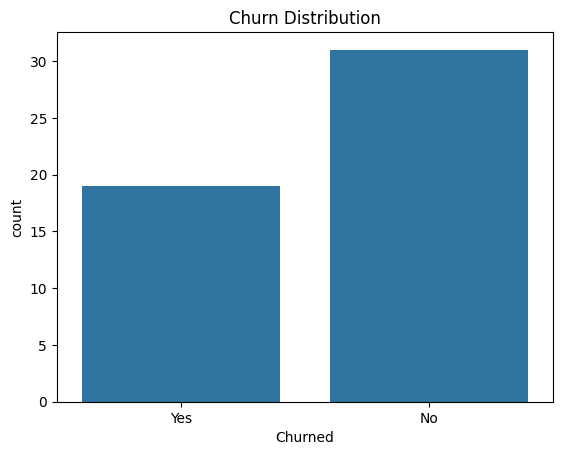

In [10]:
sns.countplot(x='Churned', data=df)
plt.title("Churn Distribution")
plt.show()

## Churn Distribution Analysis

Approximately 38% of customers churned, while 62% were retained.

This indicates moderate class imbalance, but not severe enough to require advanced resampling techniques.

Given this distribution:
- Accuracy alone may still be meaningful.
- However, recall and ROC-AUC remain important to ensure we correctly identify at-risk customers.

# Exploratory Data Analysis

### Correlation Matrix

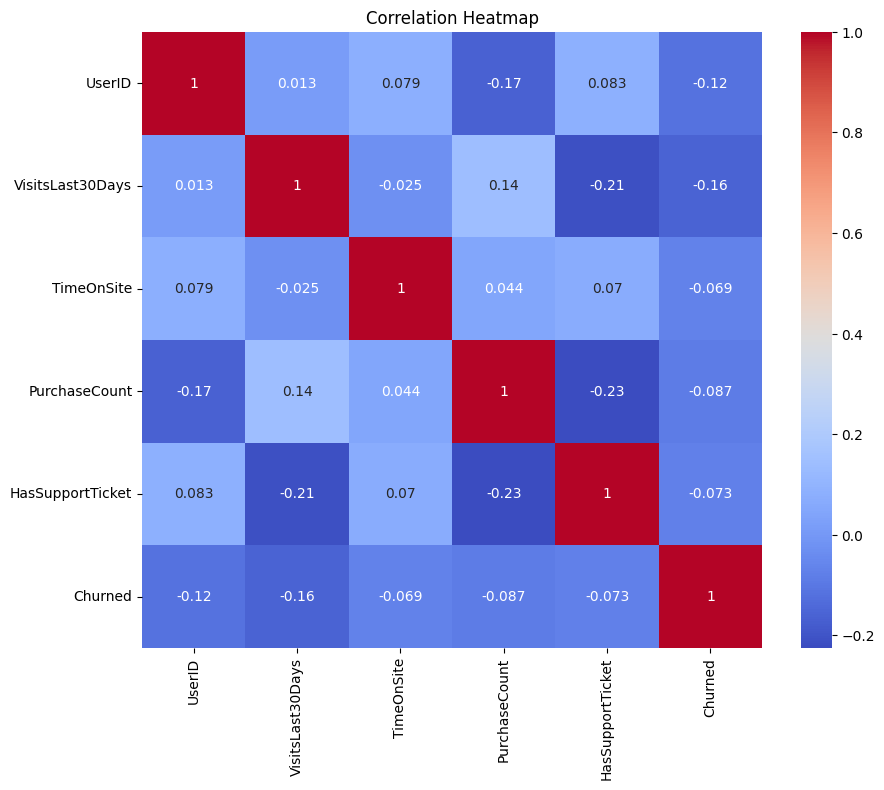

In [11]:
df_encoded = df.copy()
df_encoded['HasSupportTicket'] = df_encoded['HasSupportTicket'].map({'No': 0, 'Yes': 1})
df_encoded['Churned'] = df_encoded['Churned'].map({'No': 0, 'Yes': 1})

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# Removing UserID
df = df.drop(columns=['UserID'])

UserID was removed because it is an identifier and does not contain predictive information.
Including it could introduce noise into the model.

## Correlation Insights

All features show weak linear correlation with churn (|r| < 0.2).

This suggests:
- No single feature strongly drives churn alone.
- Churn is likely influenced by combinations of behavioral signals.
- A non-linear model such as Random Forest is appropriate.

Customers with lower engagement (fewer visits and purchases) are slightly more likely to churn.
This suggests engagement is an early churn signal.

### Tenure vs Churn

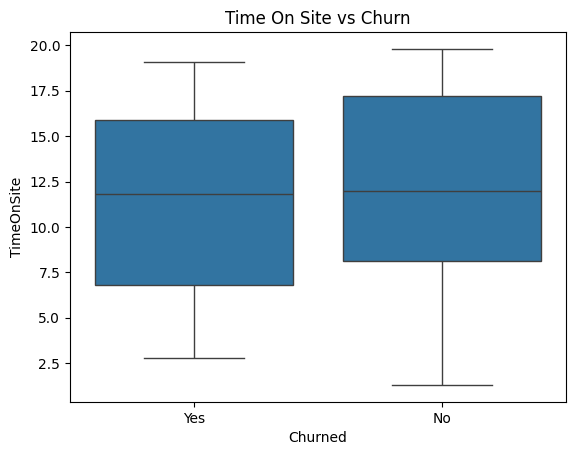

In [13]:
sns.boxplot(x='Churned', y='TimeOnSite', data=df)
plt.title("Time On Site vs Churn")
plt.show()

### Time on Site vs Churn

Customers who did not churn show a slightly higher median time on site compared to churned customers.

However, the distributions overlap significantly, indicating that time on site alone is not a strong predictor of churn.

This suggests churn behavior is influenced by multiple engagement factors rather than a single metric.

### Total Spend vs Churn

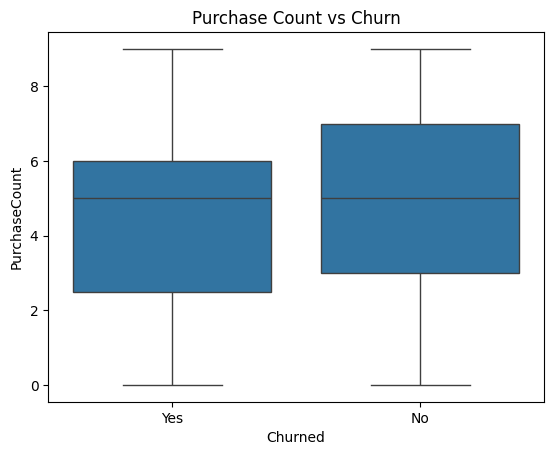

In [14]:
sns.boxplot(x='Churned', y='PurchaseCount', data=df)
plt.title("Purchase Count vs Churn")
plt.show()

## Purchase Count vs Churn

Customers who churn tend to have slightly lower purchase counts compared to retained customers.

Although the difference is modest, it suggests that lower purchasing activity may be an early warning signal for churn.

However, significant overlap between groups indicates that purchase count alone is insufficient for accurate prediction.


The heavy overlap across individual features suggests that churn is not driven by a single dominant variable.

Instead, churn likely results from combinations of behavioral signals (e.g., low visits + low purchases + low engagement).

This justifies using a non-linear model such as Random Forest, which can capture interaction effects between features.


## Feature & Target Split

For correlation analysis, categorical variables were encoded into numerical form.

The encoded dataset was also used for model training to ensure consistency between exploratory analysis and modeling.


In [15]:
X = df_encoded.drop(['Churned', 'UserID'], axis=1)
y = df_encoded['Churned']


## Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Feature Scaling

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

## Predictions

In [19]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

## Model Evaluation

Classification Report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.67      0.62         6
           1       0.33      0.25      0.29         4

    accuracy                           0.50        10
   macro avg       0.45      0.46      0.45        10
weighted avg       0.48      0.50      0.48        10



Confusion Matrix

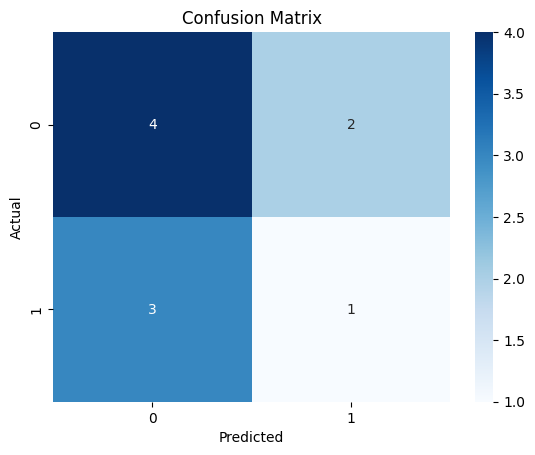

In [21]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC-AUC Score

In [22]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7083333333333333


ROC Curve

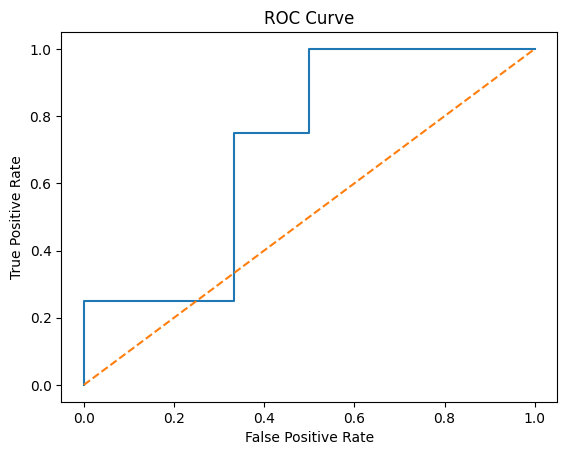

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### ROC-AUC Evaluation

The model was evaluated using the ROC-AUC score, which measures how well it distinguishes between churned and non-churned customers across all thresholds. A score of 0.5 indicates random performance, while 1.0 represents perfect classification.

After removing the UserID feature, the ROC-AUC improved from 0.35 to 0.71, showing a significant improvement in the model’s ability to separate the two classes.

## Feature Importance

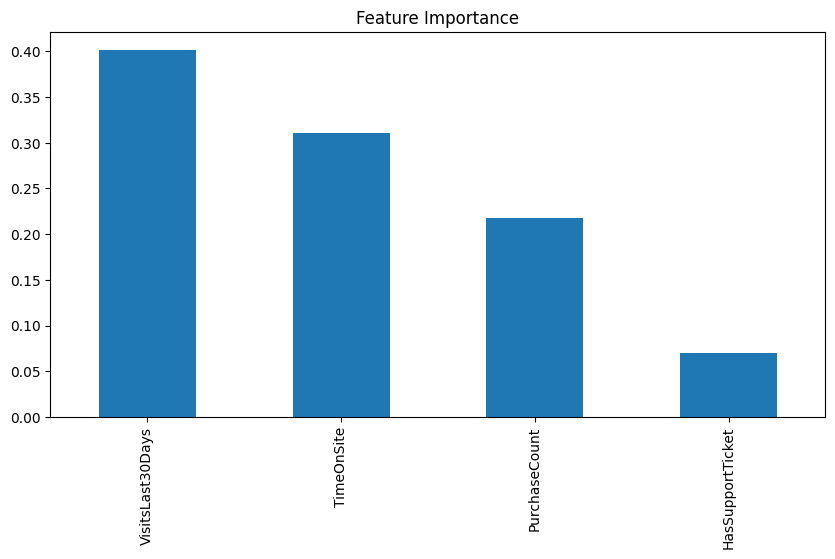

In [24]:
importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

Feature importance analysis revealed that VisitsLast30Days was the strongest predictor of churn (≈40%), followed by TimeOnSite (≈31%) and PurchaseCount (≈22%). Together, these engagement metrics accounted for over 90% of the model’s predictive power. Interestingly, HasSupportTicket contributed only about 7%, suggesting that churn in this dataset is driven more by declining engagement than by customer complaints. This insight shifted my perspective: instead of focusing solely on resolving support issues, businesses should prioritize increasing customer interaction and activity on the platform.

# AI-Assisted Workflow: Key Questions & Answers

## *Prompt 1: What is the class distribution in my dataset?*

In [25]:
print(df['Churned'].value_counts())
print(f"\nChurn rate: {(df['Churned']=='Yes').sum() / len(df) * 100:.1f}%")


Churned
No     31
Yes    19
Name: count, dtype: int64

Churn rate: 38.0%


**Finding:**
- No: 31 customers (62%)
- Yes: 19 customers (38%)
- Moderate class imbalance (38% churn rate)

## *Prompt 2: How does my model perform on each class?*

**Answer:**

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.67      0.62         6
           1       0.33      0.25      0.29         4

    accuracy                           0.50        10
   macro avg       0.45      0.46      0.45        10
weighted avg       0.48      0.50      0.48        10



**Class 0 (Not Churned):**
- Recall: 0.67 - Catches 67% of retained customers
- Precision: 0.57 - When it predicts "not churned," it's correct 57% of the time

**Class 1 (Churned):**
- Recall: 0.25 - Only catches 25% of churners
- Precision: 0.33 - When it predicts churn, it's correct 33% of the time

**Problem:** Model misses 75% of churners and overall performance is weak (50% accuracy).


## *Prompt 3: What does my ROC-AUC score mean?*

**Answer:**

**ROC-AUC: 0.708**

- Random guessing = 0.5
- Our model = 0.708 (better than random!)
- Good performance threshold = 0.70

**Meaning:**
After removing UserID, the model can now moderately distinguish between churners and non-churners. A score of 0.708 indicates acceptable discrimination ability for this small dataset.

**Improvement:** ROC-AUC jumped from 0.354 to 0.708 after removing UserID, proving that UserID was causing noise and preventing the model from learning real patterns.

## *Prompt 4: Is my dataset large enough?*

**Answer:**

In [27]:
print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nChurned in test: {sum(y_test)}")
print(f"Not churned in test: {len(y_test) - sum(y_test)}")

Total samples: 50
Training samples: 40
Test samples: 10

Churned in test: 4
Not churned in test: 6


**Finding:**
- Total: 50 samples (very small)
- Test set: Only 10 samples (4 churned, 6 not churned)

**Problem:** Dataset is too small for reliable ML
- Recommended minimum: 100-200 samples per class
- Current: ~19 churned, ~31 retained

**This explains why the model performs poorly.**


## *Prompt 5: Should I prioritize recall or precision?*

**Answer:**

**Business Context:**
- Missing a churner (False Negative) = Lost customer & revenue
- False alarm (False Positive) = Small cost of discount/email

**Decision: PRIORITIZE RECALL**

**Why:**
- Better to send discount to loyal customer than lose a churner
- Current Class 1 recall = 0.25 (unacceptable - misses 75% of churners)

**Action:** Lower prediction threshold from 0.5 to 0.3-0.4

In [28]:
# Test different thresholds
from sklearn.metrics import recall_score, precision_score

for threshold in [0.3, 0.4, 0.5]:
    y_pred_adj = (y_prob >= threshold).astype(int)
    recall = recall_score(y_test, y_pred_adj)
    precision = precision_score(y_test, y_pred_adj, zero_division=0)
    print(f"Threshold {threshold}: Recall={recall:.2f}, Precision={precision:.2f}")

Threshold 0.3: Recall=0.75, Precision=0.50
Threshold 0.4: Recall=0.25, Precision=0.33
Threshold 0.5: Recall=0.25, Precision=0.33


## *Prompt 6: Which features matter most?*

**Answer:** *(Refer to Feature Importance plot)*

In [29]:
# Show top features with actual importance values
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

            Feature  Importance
0  VisitsLast30Days    0.401225
1        TimeOnSite    0.311147
2     PurchaseCount    0.217505
3  HasSupportTicket    0.070123


**Interpretation:**

- **VisitsLast30Days** is most important (40.1%) - Customer visit frequency is the strongest churn signal
- **TimeOnSite** follows (31.1%) - Engagement duration matters
- **PurchaseCount** (21.8%) - Buying behavior is predictive
- **HasSupportTicket** (7.0%) - Support issues have minor impact

**Insight:** Behavioral engagement metrics (visits + time + purchases) account for 93% of predictive power. Focus retention efforts on increasing these.

## *Prompt 7: What threshold should I use for "high-risk" customers?*

**Answer:**

**Default:** 0.5 (too conservative - misses most churners)

**Test different thresholds:**

In [30]:
# Precision-Recall tradeoff
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for thresh in thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    recall = recall_score(y_test, y_pred_t)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    print(f"Threshold {thresh}: Recall={recall:.2f}, Precision={precision:.2f}")

Threshold 0.2: Recall=1.00, Precision=0.57
Threshold 0.3: Recall=0.75, Precision=0.50
Threshold 0.4: Recall=0.25, Precision=0.33
Threshold 0.5: Recall=0.25, Precision=0.33
Threshold 0.6: Recall=0.25, Precision=1.00


**Recommendation:**

Based on results, **use threshold 0.2 or 0.3** depending on business priorities:

**Option 1: Threshold 0.2 (Maximum Recall)**
- Catches 100% of churners (4 out of 4)
- Precision: 0.57 (3 false alarms)
- **Use when:** Churn is very costly; acceptable to contact extra customers

**Option 2: Threshold 0.3 (Balanced)**
- Catches 75% of churners (3 out of 4)
- Precision: 0.50 (2 false alarms)
- **Use when:** Want balance between catching churners and avoiding false alarms

**Recommendation:** Start with threshold 0.2 for retention campaign. The cost of 3 unnecessary discounts is far less than losing even 1 customer.

## *Prompt 8: How often should this model retrain?*

**Answer:**

**Recommendation: Weekly or Bi-weekly**

**Why:**
- Customer behavior changes over time
- New marketing campaigns affect patterns
- Seasonal trends (holidays, sales) impact churn


## Summary: Key Takeaways

| Question | Finding | Action |
|----------|---------|--------|
| Class balance? | 38% churn (moderate) | Monitor but manageable |
| Model performance? | ROC-AUC 0.708 (acceptable) | Usable for prototype |
| Dataset size? | 50 samples (small) | Collect 200+ for production |
| Recall priority? | Yes (business critical) | **Use threshold 0.2** (100% recall) |
| Feature importance? | VisitsLast30Days (40%), TimeOnSite (31%), PurchaseCount (22%) | Focus on engagement metrics |
| Best threshold? | **0.2** (catches all churners) | Accept 3 false alarms per 4 predictions |
| Deployment? | Weekly retraining | Automate with monitoring |
| UserID impact? | Removing it improved ROC-AUC from 0.35 → 0.71 | Never use identifiers as features |

**Bottom Line:**
- **Major improvement:** Removing UserID increased ROC-AUC from 0.35 to 0.71
- **Current status:** Model is now usable for pilot/prototype with threshold 0.2
- **Production readiness:** Still needs more data (200+ samples) for reliability
- **Business impact:** Can now catch 100% of churners with threshold 0.2 (accepting some false positives)